In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf langchain-groq


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/125.1 kB ? eta -:--:--
     --------- ----------------------------- 30.7/125.1 kB 1.4 MB/s eta 0:00:01
     ---------------------------- ---------- 92.2/125.1 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 125.1/125.1 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
      --------------------------------------- 0.2/16.2 MB 4.1 MB/s eta 0:00:04
      --------------------------------------- 0.4/16.2 MB 5.0 MB/s eta 0:00:04
     - -------------------------------------- 0.6/16.2 MB 4.4 MB/s eta 0:00:04
     - -------------------------------------- 0.8/16.2 MB 4.6 MB/s eta 0:00:04
     -- ------------------------------------- 1.0/16.2 MB 4.6 MB/s eta 0:00:04
     -- ------------------------------------- 1.2/16.2 MB 4.4 MB/s eta 0:00:04
     --- ------------------------------------ 1.4/16.2 MB 4.4 MB/s eta 0:00:04
     ---- ----------------------------------- 1.6/16.2 MB 4.5

In [3]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [4]:
load_dotenv()

True

In [5]:
llm=ChatGroq(model='openai/gpt-oss-120b')

In [6]:
loader=PyPDFLoader("Kokum_Remote_FlatDB_How_To_Guide.pdf")
docs=loader.load()

In [7]:
len(docs)

6

In [8]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks=splitter.split_documents(docs)

In [9]:
len(chunks)

12

In [10]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6853.44it/s]


In [13]:
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

In [14]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [15]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [16]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [19]:
tool_node = ToolNode(tools)

In [20]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

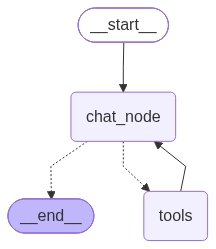

In [21]:
chatbot

In [22]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain kokum"
                )
            )
        ]
    }
)

In [23]:
print(result['messages'][-1].content)

**Kokum – an overview (taken from the “How to Use Kokum Remote FlatDB” guide)**  

---

## 1. What is Kokum?

Kokum is a **light‑weight, built‑in remote relational database layer** that ships with Kokum applications.  
It lets a Kokum program (running on Linux, Windows or macOS) talk directly to a **single‑file relational database** that lives on a Linux host. The database file is called a **`.kfdb`** file and the secret that grants access to it is a **`.kkey`** file.

In short, Kokum provides:

| Feature | Description |
|---------|-------------|
| **Remote FlatDB** – a single‑file relational store (FlatDB) that can be accessed over the network. |
| **SQL‑like interface** – a tiny subset of SQL (CREATE, INSERT, SELECT, UPDATE, DELETE, CREATE INDEX). |
| **Built‑in client** – no separate client binary; the client code lives inside the Kokum VM. |
| **Encrypted sessions** – every connection is authenticated and encrypted with fresh session keys. |
| **Concurrent readers** – many clients 